# Matrix Factorization

Implementamos un modelo de **Matrix Factorization** para recomendación explícita.  
El objetivo principal del modelo es predecir la valoración numérica que un usuario daría a una receta a partir de embeddings latentes de usuarios y recetas.

Para mantener la comparación con el notebook de Bernoulli Matrix Factorization, además de las métricas de error propias de rating prediction, se calculan las mismas métricas de evaluación binaria y de ranking: accuracy, precision, recall, F1, AUC, Precision@N, Recall@N, F1@N y NDCG@N.

**Autores:** Gallo Álvaro, García Álvaro, Recover Diego, Rízquez Tello

> Nota: Para obtener más información sobre el proyecto puedes consultar el repositorio original en [GitHub](https://github.com/DiegoRecover8/Food.com-Recommender-Systems).

## Importaciones

Se importan las librerías necesarias para cargar los datos, construir el modelo, entrenarlo con PyTorch y evaluar sus resultados mediante métricas de regresión, clasificación y ranking.

In [24]:
# Librerías básicas
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Métricas
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Utilidades
from tqdm import tqdm

## Configuración inicial

Fijamos una semilla para hacer el entrenamiento más reproducible y seleccionamos el dispositivo de cálculo. Si hay GPU disponible, se utilizará `cuda`; en caso contrario, se usará CPU.

In [25]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


## Carga de datos

Cargamos los conjuntos limpios de entrenamiento, validación y test con ratings explícitos.  
El notebook espera columnas `u`, `i` y `rating`, donde `u` es el usuario codificado, `i` es la receta codificada y `rating` es la valoración real.

Si tu proyecto utiliza nombres de fichero ligeramente distintos, puedes añadirlos en las listas de candidatos.

In [26]:
def find_file(candidates):
    """Busca el primer fichero existente dentro de varias rutas habituales del proyecto."""
    if isinstance(candidates, str):
        candidates = [candidates]

    base_dirs = [
        "",
        os.path.join("data", "processed"),
        os.path.join("..", "data", "processed"),
        os.path.join("data", "raw"),
        os.path.join("..", "data", "raw"),
    ]

    for filename in candidates:
        for base_dir in base_dirs:
            path = os.path.join(base_dir, filename)
            if os.path.exists(path):
                return path

    raise FileNotFoundError(f"No se ha encontrado ninguno de estos ficheros: {candidates}")


train_path = find_file([
    "interactions_train_clean.csv",
    "interactions_train_explicit.csv",
    "interactions_train.csv"
])

validation_path = find_file([
    "interactions_validation_clean.csv",
    "interactions_validation_explicit.csv",
    "interactions_validation.csv"
])

test_path = find_file([
    "interactions_test_clean.csv",
    "interactions_test_explicit.csv",
    "interactions_test.csv"
])

train = pd.read_csv(train_path)
validation = pd.read_csv(validation_path)
test = pd.read_csv(test_path)

required_columns = {"u", "i", "rating"}
for name, df in [("train", train), ("validation", validation), ("test", test)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"El conjunto {name} no contiene las columnas necesarias: {missing}")

print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

display(train.head())

Train: (698901, 6)
Validation: (7023, 6)
Test: (12455, 6)


,user_id,recipe_id,date,rating,u,i
0,1533,2137,2005-02-27,5.0,4913,10489
1,1533,8857,2002-08-23,5.0,4913,80790
2,1533,10332,2005-02-09,5.0,4913,60594
3,1533,10554,2002-11-14,5.0,4913,102112
4,1533,10721,2002-05-02,5.0,4913,100687


## Preparación de la variable binaria

Aunque Matrix Factorization predice ratings numéricos, se genera también la variable binaria `liked` para poder calcular las mismas métricas que en Bernoulli Matrix Factorization.

Usamos el umbral 4 porque normalmente los ratings 4 y 5 representan valoraciones positivas.

In [27]:
THETA = 4

train = train.copy()
validation = validation.copy()
test = test.copy()

train["liked"] = (train["rating"] >= THETA).astype(int)
validation["liked"] = (validation["rating"] >= THETA).astype(int)
test["liked"] = (test["rating"] >= THETA).astype(int)

print("Distribución de liked en train:")
print(train["liked"].value_counts(normalize=True).rename("proporción"))

print("\nDistribución de liked en validation:")
print(validation["liked"].value_counts(normalize=True).rename("proporción"))

print("\nDistribución de liked en test:")
print(test["liked"].value_counts(normalize=True).rename("proporción"))

print("\nRango de ratings:")
print("Train:", train["rating"].min(), "-", train["rating"].max())
print("Validation:", validation["rating"].min(), "-", validation["rating"].max())
print("Test:", test["rating"].min(), "-", test["rating"].max())

Distribución de liked en train:
liked
1    0.924265
0    0.075735
Name: proporción, dtype: float64

Distribución de liked en validation:
liked
1    0.840097
0    0.159903
Name: proporción, dtype: float64

Distribución de liked en test:
liked
1    0.834444
0    0.165556
Name: proporción, dtype: float64

Rango de ratings:
Train: 0.0 - 5.0
Validation: 0.0 - 5.0
Test: 0.0 - 5.0


## Número de usuarios y recetas

Las capas de embeddings necesitan saber cuántos usuarios y cuántas recetas distintas existen. Se calcula el máximo identificador codificado en las columnas `u` e `i`, sumando 1 porque los índices empiezan en 0.

In [28]:
num_users = int(max(train["u"].max(), validation["u"].max(), test["u"].max())) + 1
num_items = int(max(train["i"].max(), validation["i"].max(), test["i"].max())) + 1

print("Número de usuarios:", num_users)
print("Número de recetas:", num_items)

Número de usuarios: 25076
Número de recetas: 178265


## Dataset y DataLoader

Creamos una clase `Dataset` de PyTorch que devuelve para cada interacción el usuario, la receta, el rating explícito y la etiqueta binaria `liked`.  
El modelo se entrena usando `rating`, pero las métricas de clasificación se calculan usando `liked`.

In [29]:
class ExplicitRatingDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["u"].values, dtype=torch.long)
        self.items = torch.tensor(df["i"].values, dtype=torch.long)
        self.ratings = torch.tensor(df["rating"].values, dtype=torch.float32)
        self.labels = torch.tensor(df["liked"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx], self.labels[idx]

In [30]:
batch_size = 1024

train_dataset = ExplicitRatingDataset(train)
validation_dataset = ExplicitRatingDataset(validation)
test_dataset = ExplicitRatingDataset(test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batches de train:", len(train_loader))
print("Batches de validation:", len(validation_loader))
print("Batches de test:", len(test_loader))

Batches de train: 683
Batches de validation: 7
Batches de test: 13


## Definición del modelo Matrix Factorization

El modelo aprende un embedding para cada usuario y otro para cada receta.  
La predicción se obtiene mediante el producto escalar entre ambos vectores latentes, añadiendo sesgos de usuario, receta y un sesgo global.

A diferencia de Bernoulli Matrix Factorization, aquí la salida representa directamente un **rating estimado**, no un logit de probabilidad.

In [31]:
class MatrixFactorization(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, global_mean=0.0):
        super(MatrixFactorization, self).__init__()

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.user_bias = nn.Embedding(num_users, 1)
        self.item_bias = nn.Embedding(num_items, 1)
        self.global_bias = nn.Parameter(torch.tensor([global_mean], dtype=torch.float32))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, mean=0.0, std=0.01)
        nn.init.normal_(self.item_embedding.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, users, items):
        user_vec = self.user_embedding(users)
        item_vec = self.item_embedding(items)

        interaction = torch.sum(user_vec * item_vec, dim=1)
        user_b = self.user_bias(users).squeeze()
        item_b = self.item_bias(items).squeeze()

        rating_pred = interaction + user_b + item_b + self.global_bias
        return rating_pred

    def predict_rating(self, users, items, min_rating=1.0, max_rating=5.0):
        rating_pred = self.forward(users, items)
        return torch.clamp(rating_pred, min=min_rating, max=max_rating)

    def predict_proba(self, users, items, theta=4.0):
        """Convierte el rating predicho en una probabilidad aproximada de liked=1."""
        rating_pred = self.forward(users, items)
        return torch.sigmoid(rating_pred - theta)

In [32]:
embedding_dim = 64
global_mean = float(train["rating"].mean())

model = MatrixFactorization(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=embedding_dim,
    global_mean=global_mean
).to(device)

print(model)
print("Media global de rating inicial:", global_mean)

MatrixFactorization(
  (user_embedding): Embedding(25076, 64)
  (item_embedding): Embedding(178265, 64)
  (user_bias): Embedding(25076, 1)
  (item_bias): Embedding(178265, 1)
)
Media global de rating inicial: 4.574089892559891


## Funciones de evaluación

El modelo se evalúa con dos tipos de métricas:

1. **Regresión**: MSE, RMSE y MAE sobre el rating predicho.
2. **Clasificación binaria**: accuracy, precision, recall, F1 y AUC, transformando el rating predicho en una decisión binaria con el mismo umbral `THETA`.

Así se mantiene la misma lógica de evaluación del notebook de Bernoulli Matrix Factorization, pero sin perder las métricas naturales de Matrix Factorization explícita.

In [33]:
def evaluate_matrix_factorization(model, data_loader, criterion=None, theta=4.0):
    model.eval()

    all_ratings = []
    all_rating_preds = []
    all_labels = []
    all_probs = []

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for users, items, ratings, labels in data_loader:
            users = users.to(device)
            items = items.to(device)
            ratings = ratings.to(device)
            labels = labels.to(device)

            rating_preds = model(users, items)
            probs = torch.sigmoid(rating_preds - theta)

            if criterion is not None:
                loss = criterion(rating_preds, ratings)
                total_loss += loss.item() * len(ratings)
                total_examples += len(ratings)

            all_ratings.extend(ratings.cpu().numpy())
            all_rating_preds.extend(rating_preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_ratings = np.array(all_ratings)
    all_rating_preds = np.array(all_rating_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    all_binary_preds = (all_rating_preds >= theta).astype(int)

    mse = mean_squared_error(all_ratings, all_rating_preds)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(all_ratings, all_rating_preds)

    metrics = {
        "loss": total_loss / total_examples if criterion is not None else np.nan,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "accuracy": accuracy_score(all_labels, all_binary_preds),
        "precision": precision_score(all_labels, all_binary_preds, zero_division=0),
        "recall": recall_score(all_labels, all_binary_preds, zero_division=0),
        "f1": f1_score(all_labels, all_binary_preds, zero_division=0),
    }

    if len(np.unique(all_labels)) == 2:
        metrics["auc"] = roc_auc_score(all_labels, all_probs)
    else:
        metrics["auc"] = np.nan

    return metrics

## Entrenamiento del modelo

El modelo se entrena minimizando `MSELoss`, que penaliza la diferencia entre el rating real y el rating predicho.  
Se utiliza Adam como optimizador y `weight_decay` como regularización para reducir el riesgo de sobreajuste en los embeddings.

In [34]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

epochs = 10

os.makedirs("models", exist_ok=True)
best_model_path = os.path.join("models", "matrix_factorization_best.pth")
best_val_loss = float("inf")

train_losses = []
validation_losses = []
validation_rmses = []
validation_maes = []
validation_aucs = []
validation_f1s = []

In [35]:
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for users, items, ratings, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs}"):
        users = users.to(device)
        items = items.to(device)
        ratings = ratings.to(device)

        optimizer.zero_grad()

        rating_preds = model(users, items)
        loss = criterion(rating_preds, ratings)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(ratings)

    avg_train_loss = total_loss / len(train_dataset)
    val_metrics = evaluate_matrix_factorization(
        model,
        validation_loader,
        criterion=criterion,
        theta=THETA
    )

    train_losses.append(avg_train_loss)
    validation_losses.append(val_metrics["loss"])
    validation_rmses.append(val_metrics["rmse"])
    validation_maes.append(val_metrics["mae"])
    validation_aucs.append(val_metrics["auc"])
    validation_f1s.append(val_metrics["f1"])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "validation_loss": val_metrics["loss"],
            "validation_rmse": val_metrics["rmse"],
            "validation_mae": val_metrics["mae"],
            "validation_auc": val_metrics["auc"],
            "validation_f1": val_metrics["f1"],
            "num_users": num_users,
            "num_items": num_items,
            "embedding_dim": embedding_dim,
            "global_mean": global_mean,
            "theta": THETA,
        }, best_model_path)

        print(f"Nuevo mejor modelo guardado en epoch {epoch + 1}")

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val RMSE: {val_metrics['rmse']:.4f} | "
        f"Val MAE: {val_metrics['mae']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f}"
    )

Epoch 1/10: 100%|██████████| 683/683 [00:21<00:00, 31.43it/s]


Nuevo mejor modelo guardado en epoch 1
Epoch 1/10 | Train Loss: 0.8896 | Val Loss: 1.7398 | Val RMSE: 1.3190 | Val MAE: 0.8581 | Val AUC: 0.6722 | Val F1: 0.9131


Epoch 2/10: 100%|██████████| 683/683 [00:18<00:00, 37.80it/s]


Nuevo mejor modelo guardado en epoch 2
Epoch 2/10 | Train Loss: 0.8282 | Val Loss: 1.6983 | Val RMSE: 1.3032 | Val MAE: 0.8549 | Val AUC: 0.6763 | Val F1: 0.9131


Epoch 3/10: 100%|██████████| 683/683 [00:20<00:00, 32.98it/s]


...

Nuevo mejor modelo guardado en epoch 8
Epoch 8/10 | Train Loss: 0.3753 | Val Loss: 1.6187 | Val RMSE: 1.2723 | Val MAE: 0.8357 | Val AUC: 0.6785 | Val F1: 0.9105


Epoch 9/10: 100%|██████████| 683/683 [00:17<00:00, 40.07it/s]


Nuevo mejor modelo guardado en epoch 9
Epoch 9/10 | Train Loss: 0.3347 | Val Loss: 1.6142 | Val RMSE: 1.2705 | Val MAE: 0.8342 | Val AUC: 0.6783 | Val F1: 0.9094


Epoch 10/10: 100%|██████████| 683/683 [00:16<00:00, 42.30it/s]


Nuevo mejor modelo guardado en epoch 10
Epoch 10/10 | Train Loss: 0.3029 | Val Loss: 1.6112 | Val RMSE: 1.2693 | Val MAE: 0.8322 | Val AUC: 0.6783 | Val F1: 0.9080


## Evolución del entrenamiento

Representamos la evolución de la pérdida en entrenamiento y validación. Si la pérdida de entrenamiento sigue bajando mientras la de validación empieza a subir, podría existir sobreajuste.

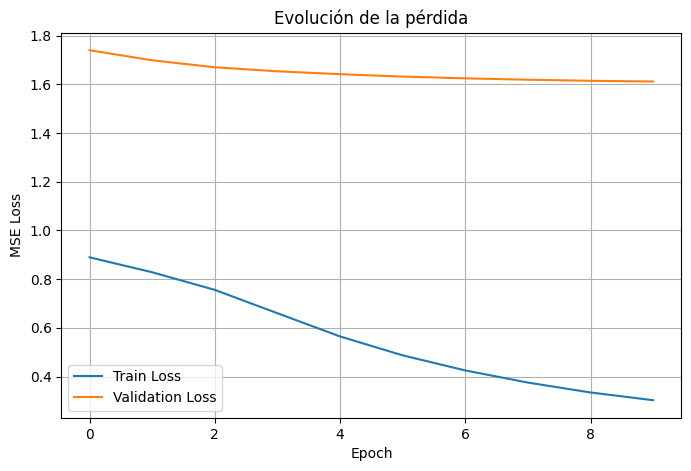

In [36]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(validation_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Evolución de la pérdida")
plt.legend()
plt.grid(True)
plt.show()

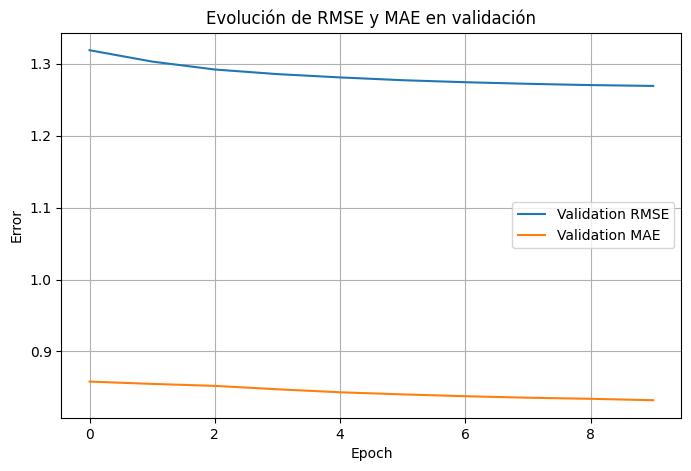

In [37]:
plt.figure(figsize=(8, 5))

plt.plot(validation_rmses, label="Validation RMSE")
plt.plot(validation_maes, label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("Error")
plt.title("Evolución de RMSE y MAE en validación")
plt.legend()
plt.grid(True)
plt.show()

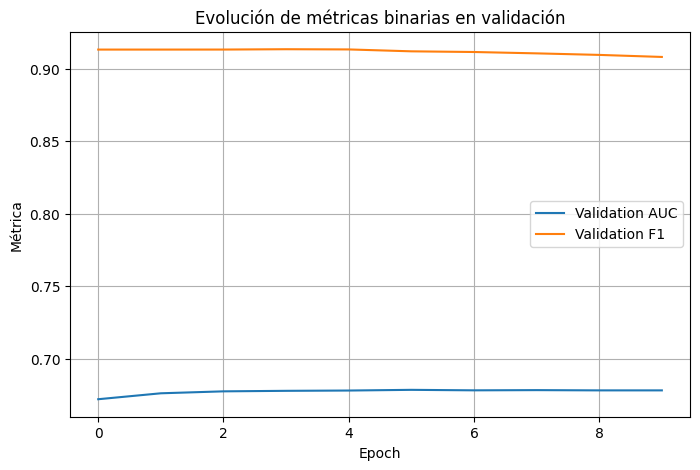

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(validation_aucs, label="Validation AUC")
plt.plot(validation_f1s, label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("Métrica")
plt.title("Evolución de métricas binarias en validación")
plt.legend()
plt.grid(True)
plt.show()

## Carga del mejor modelo

Para la evaluación final en test, se carga el checkpoint con mejor pérdida de validación. Esto evita evaluar necesariamente el modelo de la última época, que podría estar sobreajustado.

In [39]:
checkpoint = torch.load(best_model_path, map_location=device)

best_model = MatrixFactorization(
    num_users=checkpoint["num_users"],
    num_items=checkpoint["num_items"],
    embedding_dim=checkpoint["embedding_dim"],
    global_mean=checkpoint["global_mean"]
).to(device)

best_model.load_state_dict(checkpoint["model_state_dict"])

print("Mejor época:", checkpoint["epoch"])
print("Validation Loss:", checkpoint["validation_loss"])
print("Validation RMSE:", checkpoint["validation_rmse"])
print("Validation MAE:", checkpoint["validation_mae"])
print("Validation AUC:", checkpoint["validation_auc"])
print("Validation F1:", checkpoint["validation_f1"])

Mejor época: 10
Validation Loss: 1.6112401464904422
Validation RMSE: 1.269346346961424
Validation MAE: 0.8321815729141235
Validation AUC: 0.6783031981526481
Validation F1: 0.9080241040279099


## Evaluación en test

Se evalúa el mejor modelo sobre el conjunto de test.  
Además de RMSE y MAE, se mantienen las mismas métricas binarias usadas en Bernoulli Matrix Factorization para facilitar la comparación entre modelos.

In [40]:
test_metrics = evaluate_matrix_factorization(
    best_model,
    test_loader,
    criterion=criterion,
    theta=THETA
)

print("Resultados en test - Matrix Factorization")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"MSE: {test_metrics['mse']:.4f}")
print(f"RMSE: {test_metrics['rmse']:.4f}")
print(f"MAE: {test_metrics['mae']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall: {test_metrics['recall']:.4f}")
print(f"F1: {test_metrics['f1']:.4f}")
print(f"AUC: {test_metrics['auc']:.4f}")

Resultados en test - Matrix Factorization
Loss: 1.7208
MSE: 1.7208
RMSE: 1.3118
MAE: 0.8623
Accuracy: 0.8316
Precision: 0.8442
Recall: 0.9788
F1: 0.9065
AUC: 0.6723


## Predicciones para métricas de ranking

Además de las métricas de regresión y clasificación, se calculan métricas de ranking.  
Para ello, se generan las puntuaciones predichas por el modelo y se almacenan en un diccionario con claves `(usuario, receta)`.

In [41]:
def get_prediction_dict(model, data_loader):
    model.eval()
    prediction_dict = {}

    with torch.no_grad():
        for users, items, ratings, labels in data_loader:
            users_device = users.to(device)
            items_device = items.to(device)

            preds = model.predict_rating(users_device, items_device).cpu().numpy()
            users_np = users.cpu().numpy()
            items_np = items.cpu().numpy()

            for u, i, pred in zip(users_np, items_np, preds):
                prediction_dict[(int(u), int(i))] = float(pred)

    return prediction_dict


mf_predictions = get_prediction_dict(best_model, test_loader)

print("Número de predicciones:", len(mf_predictions))
print("Número de filas en test:", len(test))

Número de predicciones: 12455
Número de filas en test: 12455


## Métricas de ranking

Para calcular Precision@N, Recall@N, F1@N y NDCG@N se ordenan las recetas de cada usuario según el rating predicho por el modelo. Después se comprueba si las recetas recomendadas son realmente relevantes.

In [42]:
test_ratings = {
    (int(row["u"]), int(row["i"])): float(row["liked"])
    for _, row in test.iterrows()
}

test_users = test["u"].unique()

N = 10

def get_user_predictions(predictions, user):
    return {
        item: pred
        for (u, item), pred in predictions.items()
        if u == user
    }


def get_user_ratings(ratings, user):
    return {
        item: rating
        for (u, item), rating in ratings.items()
        if u == user
    }


def precision_at_n(predictions, ratings, users, N=10):
    precisions = []

    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)

        if len(user_preds) == 0:
            continue

        top_n_items = sorted(user_preds, key=user_preds.get, reverse=True)[:N]

        relevant_recommended = [
            item for item in top_n_items
            if item in user_true and user_true[item] == 1
        ]

        precisions.append(len(relevant_recommended) / N)

    return np.mean(precisions)


def recall_at_n(predictions, ratings, users, N=10):
    recalls = []

    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)

        relevant_items = [
            item for item, rating in user_true.items()
            if rating == 1
        ]

        if len(relevant_items) == 0:
            continue

        top_n_items = sorted(user_preds, key=user_preds.get, reverse=True)[:N]

        relevant_recommended = [
            item for item in top_n_items
            if item in relevant_items
        ]

        recalls.append(len(relevant_recommended) / len(relevant_items))

    return np.mean(recalls)


def f1_at_n(precision, recall):
    if precision + recall == 0:
        return 0
    return 2 * precision * recall / (precision + recall)


def ndcg_at_n(predictions, ratings, users, N=10):
    ndcgs = []

    for user in users:
        user_preds = get_user_predictions(predictions, user)
        user_true = get_user_ratings(ratings, user)

        if len(user_preds) == 0:
            continue

        top_n_items = sorted(user_preds, key=user_preds.get, reverse=True)[:N]

        dcg = 0.0
        for rank, item in enumerate(top_n_items):
            relevance = 1 if item in user_true and user_true[item] == 1 else 0
            dcg += relevance / np.log2(rank + 2)

        ideal_relevances = sorted(
            [1 if rating == 1 else 0 for rating in user_true.values()],
            reverse=True
        )[:N]

        idcg = 0.0
        for rank, relevance in enumerate(ideal_relevances):
            idcg += relevance / np.log2(rank + 2)

        if idcg > 0:
            ndcgs.append(dcg / idcg)

    return np.mean(ndcgs)

In [43]:
precision_mf = precision_at_n(
    mf_predictions,
    test_ratings,
    test_users,
    N=N
)

recall_mf = recall_at_n(
    mf_predictions,
    test_ratings,
    test_users,
    N=N
)

f1_mf = f1_at_n(precision_mf, recall_mf)

ndcg_mf = ndcg_at_n(
    mf_predictions,
    test_ratings,
    test_users,
    N=N
)

print(f"Precision@{N}: {precision_mf:.4f}")
print(f"Recall@{N}: {recall_mf:.4f}")
print(f"F1@{N}: {f1_mf:.4f}")
print(f"NDCG@{N}: {ndcg_mf:.4f}")

Precision@10: 0.0834
Recall@10: 1.0000
F1@10: 0.1540
NDCG@10: 1.0000


## Resumen de resultados

Se resumen las métricas principales del modelo Matrix Factorization.  

In [44]:

# Baseline para ratings, media por ítem
global_mean = float(train["rating"].mean())
item_mean = train.groupby("i")["rating"].mean().to_dict()

# Predicciones baseline en los mismos pares (u,i) del test
baseline_predictions = {
    (int(row["u"]), int(row["i"])): float(item_mean.get(int(row["i"]), global_mean))
    for _, row in test.iterrows()
}

# Metricas de regresión baseline (rating)
y_true_rating = test["rating"].astype(float).values
y_pred_rating = np.array(
    [baseline_predictions[(int(u), int(i))] for u, i in zip(test["u"].values, test["i"].values)],
    dtype=float
)

baseline_mse  = float(mean_squared_error(y_true_rating, y_pred_rating))
baseline_rmse = float(np.sqrt(baseline_mse))
baseline_mae  = float(mean_absolute_error(y_true_rating, y_pred_rating))

# Metricas binarias baseline (liked)
y_true_liked = test["liked"].astype(int).values
y_score = 1.0 / (1.0 + np.exp(-(y_pred_rating - THETA)))  # sigmoid

y_pred_liked = (y_pred_rating >= THETA).astype(int)

baseline_acc  = float(accuracy_score(y_true_liked, y_pred_liked))
baseline_prec = float(precision_score(y_true_liked, y_pred_liked, zero_division=0))
baseline_rec  = float(recall_score(y_true_liked, y_pred_liked, zero_division=0))
baseline_f1   = float(f1_score(y_true_liked, y_pred_liked, zero_division=0))


baseline_auc = float(roc_auc_score(y_true_liked, y_score)) if len(np.unique(y_true_liked)) == 2 else np.nan

precision_base = precision_at_n(baseline_predictions, test_ratings, test_users, N=N)
recall_base    = recall_at_n(baseline_predictions, test_ratings, test_users, N=N)
f1_base_rank   = f1_at_n(precision_base, recall_base)
ndcg_base      = ndcg_at_n(baseline_predictions, test_ratings, test_users, N=N)

# --- Tabla comparativa final ---
results_compare = pd.DataFrame([
    {
        "Modelo": "Baseline (media global)",
        "Loss": np.nan,                 # no entrenamos, no hay loss de modelo
        "MSE": baseline_mse,
        "RMSE": baseline_rmse,
        "MAE": baseline_mae,
        "Accuracy": baseline_acc,
        "Precision": baseline_prec,
        "Recall": baseline_rec,
        "F1": baseline_f1,
        "AUC": baseline_auc,
        f"Precision@{N}": precision_base,
        f"Recall@{N}": recall_base,
        f"F1@{N}": f1_base_rank,
        f"NDCG@{N}": ndcg_base,
    },
    {
        "Modelo": "Matrix Factorization",
        "Loss": test_metrics["loss"],
        "MSE": test_metrics["mse"],
        "RMSE": test_metrics["rmse"],
        "MAE": test_metrics["mae"],
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1": test_metrics["f1"],
        "AUC": test_metrics["auc"],
        f"Precision@{N}": precision_mf,
        f"Recall@{N}": recall_mf,
        f"F1@{N}": f1_mf,
        f"NDCG@{N}": ndcg_mf,
    }
])

results_compare

,Modelo,Loss,MSE,RMSE,MAE,Accuracy,Precision,Recall,F1,AUC,Precision@10,Recall@10,F1@10,NDCG@10
0,Baseline (media global),NaN,1.921770,1.386279,0.879823,0.834444,0.834444,1.000000,0.909751,0.500000,0.083444,1.0,0.154035,1.0
1,Matrix Factorization,1.720769,1.720769,1.311781,0.862295,0.831554,0.844162,0.978832,0.906523,0.672334,0.083444,1.0,0.154035,1.0


En esta comparación, **Matrix Factorization** mejora al baseline de forma clara en la parte de predicción de rating. Baja el **RMSE** (de $\approx 1.386$ a $\approx 1.312$) y también el MAE (de $\approx 0.880$ a $\approx 0.862$). Es decir, el modelo está aprendiendo señal adicional más allá de “ponerle a cada receta su media”, aunque la mejora no sea enorme.

En las métricas binarias con el umbral `THETA = 4`, ambos modelos se comportan de forma parecida, pero el baseline sale con *recall* 1.0, lo que sugiere que con ese criterio está tendiendo a marcar muchos casos como positivos (por eso también el AUC del baseline no es especialmente informativo). El MF, en cambio, mantiene un equilibrio razonable y obtiene un AUC $\approx 0.67$, lo que indica cierta capacidad de ordenar mejor los casos positivos por encima de los negativos.

Por último, las métricas **Top-N** (Precision@10, Recall@10, F1@10 y nDCG@10) salen idénticas en ambos modelos, así que en este experimento no están ayudando a diferenciar. En consecuencia, para comparar modelos aquí tiene más sentido apoyarse sobre todo en **RMSE/MAE** (y, si se quiere ranking, revisar el protocolo de evaluación Top-N para que sea más discriminativo).